## 1. Importando as bibliotecas e leitura dos dados

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,  roc_curve, roc_auc_score

#Caminho dos dados
caminho_dados = '../Dados_Treino_Teste'

X_treino = pd.read_csv(f'{caminho_dados}/X_treino.csv')
X_teste = pd.read_csv(f'{caminho_dados}/X_teste.csv')
y_treino = pd.read_csv(f'{caminho_dados}/y_treino.csv').squeeze()
y_teste = pd.read_csv(f'{caminho_dados}/y_teste.csv').squeeze()

## 2. Ajuste de Hiperparâmetros para o RandomizedSearchCV no XGBoost

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# Instanciando o modelo base
xgb_base = XGBClassifier(eval_metric='logloss')

# Espaço de busca dos hiperparâmetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,  
    scoring='accuracy', 
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Executando a busca
random_search.fit(X_treino, y_treino)

# Melhor modelo encontrado
modelo_xgb = random_search.best_estimator_

# Exibindo os melhores hiperparâmetros
print("Melhores hiperparâmetros encontrados:")
print(random_search.best_params_)


#Tempo de execução 
inicio = time.time()
random_search.fit(X_treino, y_treino)
fim = time.time()

print(f"Tempo total: {(fim - inicio)/60:.2f} minutos")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhores hiperparâmetros encontrados:
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Tempo total: 2.32 minutos


In [12]:
# Acessando o melhor modelo encontrado para XGBoost
melhor_modelo_xgb = random_search.best_estimator_

# Exibindo os melhores hiperparâmetros encontrados
print("\nMelhores hiperparâmetros encontrados para o XGBoost:")
for parametro, valor in random_search.best_params_.items():
    print(f"  - {parametro}: {valor}")


# Score médio de validação cruzada
print(f"\nScore de validação cruzada do melhor modelo: {random_search.best_score_:.4f}")



Melhores hiperparâmetros encontrados para o XGBoost:
  - subsample: 0.6
  - n_estimators: 300
  - max_depth: 5
  - learning_rate: 0.1
  - gamma: 0.3
  - colsample_bytree: 0.8

Score de validação cruzada do melhor modelo: 0.9999


## 3. Treinando o Modelo XGBoost

In [15]:
# Acessando o melhor modelo encontrado no RandomizedSearchCV
melhor_modelo_xgb = random_search.best_estimator_

# Treinando o modelo com os dados de treino
melhor_modelo_xgb.fit(X_treino, y_treino)

# Previsões no conjunto de teste
y_pred_teste = melhor_modelo_xgb.predict(X_teste)
y_proba = melhor_modelo_xgb.predict_proba(X_teste)[:, 1]

# Avaliação com métricas
print("\nAvaliação no Conjunto de Teste (XGBoost):")
print(f"Acurácia:  {accuracy_score(y_teste, y_pred_teste):.4f}")
print(f"Precisão:  {precision_score(y_teste, y_pred_teste):.4f}")
print(f"Recall:    {recall_score(y_teste, y_pred_teste):.4f}")
print(f"F1-score:  {f1_score(y_teste, y_pred_teste):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_teste, y_proba):.4f}")

#########################################################################

# Previsão de quantidades de Cancelamentos
quantidade_cancelamentos_previstos = (y_pred_teste == 1).sum()
quantidade_nao_cancelamentos_previstos = (y_pred_teste == 0).sum()

# Quantidades reais
quantidade_cancelamentos_reais = (y_teste == 1).sum()
quantidade_nao_cancelamentos_reais = (y_teste == 0).sum()

# Impressão dos resultados
print(f"\nQuantidade prevista de cancelamentos: {quantidade_cancelamentos_previstos}")
print(f"Quantidade prevista de não cancelamentos: {quantidade_nao_cancelamentos_previstos}")
print(f"\nQuantidade real de cancelamentos: {quantidade_cancelamentos_reais}")
print(f"Quantidade real de não cancelamentos: {quantidade_nao_cancelamentos_reais}")

print(f"\nDiferença (real - previsto) - Cancelamentos: {quantidade_cancelamentos_previstos - quantidade_cancelamentos_reais}")
print(f"Diferença (real - previsto) - Não cancelamentos: {quantidade_nao_cancelamentos_previstos - quantidade_nao_cancelamentos_reais}")



Avaliação no Conjunto de Teste (XGBoost):
Acurácia:  0.9998
Precisão:  1.0000
Recall:    0.9997
F1-score:  0.9998
AUC-ROC:   1.0000

Quantidade prevista de cancelamentos: 49985
Quantidade prevista de não cancelamentos: 38182

Quantidade real de cancelamentos: 50000
Quantidade real de não cancelamentos: 38167

Diferença (real - previsto) - Cancelamentos: -15
Diferença (real - previsto) - Não cancelamentos: 15


## 4. Matriz de Confusão

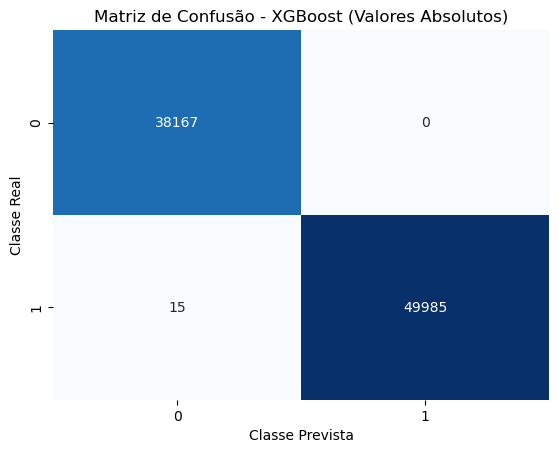

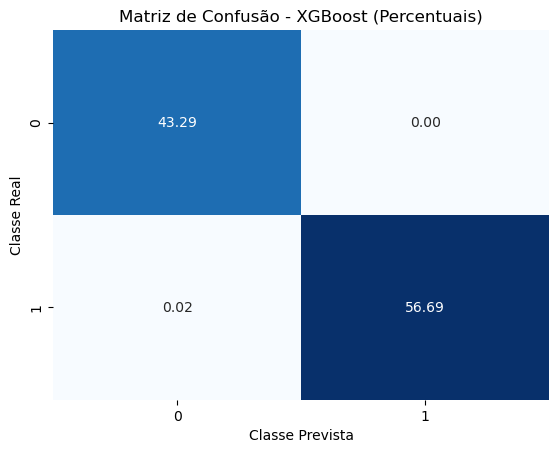

Matriz de Confusão - Interpretação (XGBoost):
→ Verdadeiros Negativos (TN): 38167
→ Falsos Positivos (FP): 0
→ Falsos Negativos (FN): 15
→ Verdadeiros Positivos (TP): 49985

Interpretação:
- O modelo acertou 49985 casos de cancelamento e 38167 casos de não cancelamento.
- Ele errou em 0 casos ao prever cancelamento onde não houve (falsos positivos).
- Cometeu 15 erros ao deixar de prever cancelamentos que ocorreram (falsos negativos).
- Falsos negativos são particularmente importantes, pois indicam clientes que cancelaram sem serem previstos pelo modelo.


In [19]:

# Matriz de confusão para o modelo XGBoost
cm_xgb = confusion_matrix(y_teste, y_pred_teste)
cm_xgb_normalizado = cm_xgb / cm_xgb.sum() * 100

# Plot - valores absolutos (azul e branco)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão - XGBoost (Valores Absolutos)")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

# Plot - percentuais (azul e branco)
sns.heatmap(cm_xgb_normalizado, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão - XGBoost (Percentuais)")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

# Explicação textual da matriz de confusão
tn, fp, fn, tp = cm_xgb.ravel()

print("Matriz de Confusão - Interpretação (XGBoost):")
print(f"→ Verdadeiros Negativos (TN): {tn}")
print(f"→ Falsos Positivos (FP): {fp}")
print(f"→ Falsos Negativos (FN): {fn}")
print(f"→ Verdadeiros Positivos (TP): {tp}")

print("\nInterpretação:")
print(f"- O modelo acertou {tp} casos de cancelamento e {tn} casos de não cancelamento.")
print(f"- Ele errou em {fp} casos ao prever cancelamento onde não houve (falsos positivos).")
print(f"- Cometeu {fn} erros ao deixar de prever cancelamentos que ocorreram (falsos negativos).")
print("- Falsos negativos são particularmente importantes, pois indicam clientes que cancelaram sem serem previstos pelo modelo.")

## 5. Curva ROC

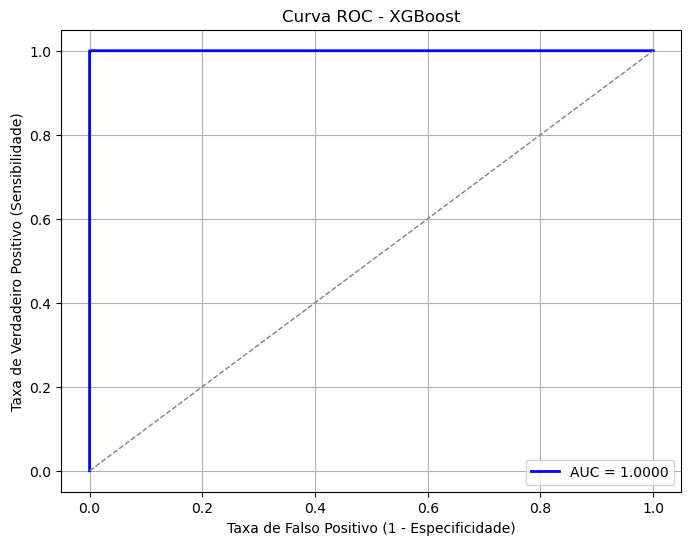

Interpretação da Curva ROC - XGBoost:
- A curva ROC mostra a relação entre a Sensibilidade (TPR) e a Especificidade (1 - FPR) para vários thresholds de decisão.
- O valor AUC (Área Sob a Curva) é 1.0000, indicando a capacidade do modelo de distinguir entre as classes.
- Excelente desempenho: modelo altamente discriminativo.
- Quanto mais próximo de 1, melhor o modelo. Um valor próximo a 0.5 indica um modelo aleatório.


In [21]:

# Probabilidades preditas para a classe positiva (XGBoost)
y_proba_xgb = melhor_modelo_xgb.predict_proba(X_teste)[:, 1]

# Calcula taxas de falso positivo e verdadeiro positivo
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_teste, y_proba_xgb)

# Calcula área sob a curva ROC
auc_score_xgb = roc_auc_score(y_teste, y_proba_xgb)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f"AUC = {auc_score_xgb:.4f}")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("Taxa de Falso Positivo (1 - Especificidade)")
plt.ylabel("Taxa de Verdadeiro Positivo (Sensibilidade)")
plt.title("Curva ROC - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Interpretação detalhada da curva ROC
print("Interpretação da Curva ROC - XGBoost:")
print(f"- A curva ROC mostra a relação entre a Sensibilidade (TPR) e a Especificidade (1 - FPR) para vários thresholds de decisão.")
print(f"- O valor AUC (Área Sob a Curva) é {auc_score_xgb:.4f}, indicando a capacidade do modelo de distinguir entre as classes.")
if auc_score_xgb > 0.9:
    print("- Excelente desempenho: modelo altamente discriminativo.")
elif auc_score_xgb > 0.8:
    print("- Bom desempenho: modelo com boa capacidade discriminativa.")
elif auc_score_xgb > 0.7:
    print("- Desempenho razoável: modelo com capacidade moderada.")
else:
    print("- Desempenho fraco: modelo com pouca capacidade de discriminação.")
print("- Quanto mais próximo de 1, melhor o modelo. Um valor próximo a 0.5 indica um modelo aleatório.")

## 6. Avaliação de Múltiplas Métricas com o XGBoost

In [23]:

# Reunindo todos os dados
X = pd.concat([X_treino, X_teste], axis=0)
y = pd.concat([y_treino, y_teste], axis=0)

# Avaliando as principais métricas
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultado = cross_validate(
    melhor_modelo_xgb, X, y, cv=5, scoring=metricas, return_train_score=False
)

# Criando DataFrame com resultados
df_resultados_cv = pd.DataFrame(columns=['Métrica', 'Média', 'Desvio Padrão'])

for metrica in metricas:
    scores = resultado[f'test_{metrica}']
    media = np.mean(scores)
    desvio = np.std(scores)
    
    df_resultados_cv = pd.concat([
        df_resultados_cv,
        pd.DataFrame({
            'Métrica': [metrica.upper()],
            'Média': [f'{media:.4f}'],
            'Desvio Padrão': [f'{desvio:.4f}']
        })
    ], ignore_index=True)

# Exibindo resultados
display(df_resultados_cv)

,Métrica,Média,Desvio Padrão
0,ACCURACY,0.9999,0.0001
1,PRECISION,1.0000,0.0000
2,RECALL,0.9998,0.0001
3,F1,0.9999,0.0000
4,ROC_AUC,1.0000,0.0000


## 7. Comparar Desempenho no Treino e Teste (Checar Overfitting)

In [25]:

# Avaliação no conjunto de treino
y_pred_treino_xgb = melhor_modelo_xgb.predict(X_treino)

metricas_treino_xgb = {
    'Acurácia': accuracy_score(y_treino, y_pred_treino_xgb),
    'Precisão': precision_score(y_treino, y_pred_treino_xgb),
    'Recall': recall_score(y_treino, y_pred_treino_xgb),
    'F1-score': f1_score(y_treino, y_pred_treino_xgb)
}

# Avaliação no conjunto de teste (valores já calculados anteriormente)
resultados_xgb = {
    'Acurácia': accuracy_score(y_teste, y_pred_teste),
    'Precisão': precision_score(y_teste, y_pred_teste),
    'Recall': recall_score(y_teste, y_pred_teste),
    'F1-score': f1_score(y_teste, y_pred_teste)
}

# Comparação treino vs teste
df_comparacao_xgb = pd.DataFrame({
    'Métrica': list(metricas_treino_xgb.keys()),
    'Treino': [round(metricas_treino_xgb[m], 4) for m in metricas_treino_xgb],
    'Teste': [round(resultados_xgb[m], 4) for m in resultados_xgb]
}).set_index('Métrica')

# Exibir
display(df_comparacao_xgb)


,Treino,Teste
Métrica,,
Acurácia,0.9999,0.9998
Precisão,1.0000,1.0000
Recall,0.9998,0.9997
F1-score,0.9999,0.9998


## Comentários sobre o resultado acima:

- A precisão perfeita (1.0000) sugere que o modelo não está classificando falsamente clientes como canceladores.
- O recall altíssimo (0.9997) mostra que ele está capturando quase todos os cancelamentos reais.
- As diferenças entre treino e teste são mínimas (0.0001 ou menos), o que indica:
- Nenhum sinal de overfitting.
- Excelente generalização do modelo.


## 8. Importância das variaveis - XGBoost

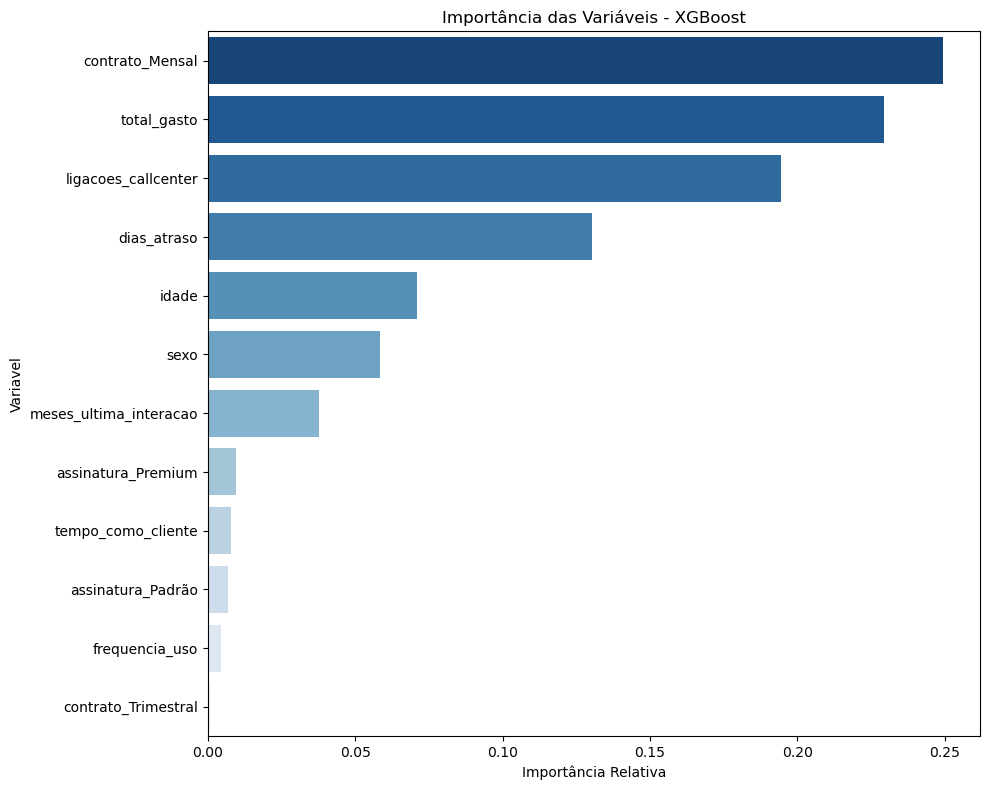

📌 Interpretação da Importância das Variáveis - XGBoost:
- A variável mais influente no modelo é **contrato_Mensal**, com importância relativa de 0.2495.
- Isso significa que essa variável foi a que mais contribuiu para as decisões do modelo ao longo das árvores.
- As variáveis no topo do gráfico foram mais frequentemente utilizadas em divisões que aumentaram a pureza dos nós.
- Já as variáveis com menor importância tiveram pouca ou nenhuma influência nas decisões do modelo.
- Essa análise ajuda a entender quais atributos mais impactam a previsão de cancelamentos e pode orientar futuras estratégias de negócio ou seleção de variáveis.


In [33]:
# Importância das variáveis segundo o XGBoost
importancias_xgb = melhor_modelo_xgb.feature_importances_
variaveis = X_treino.columns

# Criação do DataFrame de importância
df_importancia_xgb = pd.DataFrame({
    'Variavel': variaveis,
    'Importancia': importancias_xgb
}).sort_values(by='Importancia', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importancia',
    y='Variavel',
    data=df_importancia_xgb.head(20),
    hue='Variavel',
    dodge=False,
    palette='Blues_r',
    legend=False
)
plt.title("Importância das Variáveis - XGBoost")
plt.xlabel("Importância Relativa")
plt.tight_layout()
plt.show()


# Interpretação da importância das variáveis
print("📌 Interpretação da Importância das Variáveis - XGBoost:")
variavel_top1 = df_importancia_xgb.iloc[0]['Variavel']
importancia_top1 = df_importancia_xgb.iloc[0]['Importancia']

print(f"- A variável mais influente no modelo é **{variavel_top1}**, com importância relativa de {importancia_top1:.4f}.")
print("- Isso significa que essa variável foi a que mais contribuiu para as decisões do modelo ao longo das árvores.")
print("- As variáveis no topo do gráfico foram mais frequentemente utilizadas em divisões que aumentaram a pureza dos nós.")
print("- Já as variáveis com menor importância tiveram pouca ou nenhuma influência nas decisões do modelo.")
print("- Essa análise ajuda a entender quais atributos mais impactam a previsão de cancelamentos e pode orientar futuras estratégias de negócio ou seleção de variáveis.")

## 9. Salvando o Modelo XGBoost

In [34]:
import joblib

# Salvar o modelo treinado
joblib.dump(melhor_modelo_xgb, 'modelo_XGBoost.pkl')

# Carregar o modelo treinado
modelo_xgb_carregado = joblib.load('modelo_XGBoost.pkl')